In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [8]:
FARS = pd.read_csv('/data/esplab/aelyoussoufi/FARSNO2.csv')
ENSO = pd.read_csv('../data/ENSO/ENSOMONTHLY.csv')

<Figure size 1500x600 with 0 Axes>

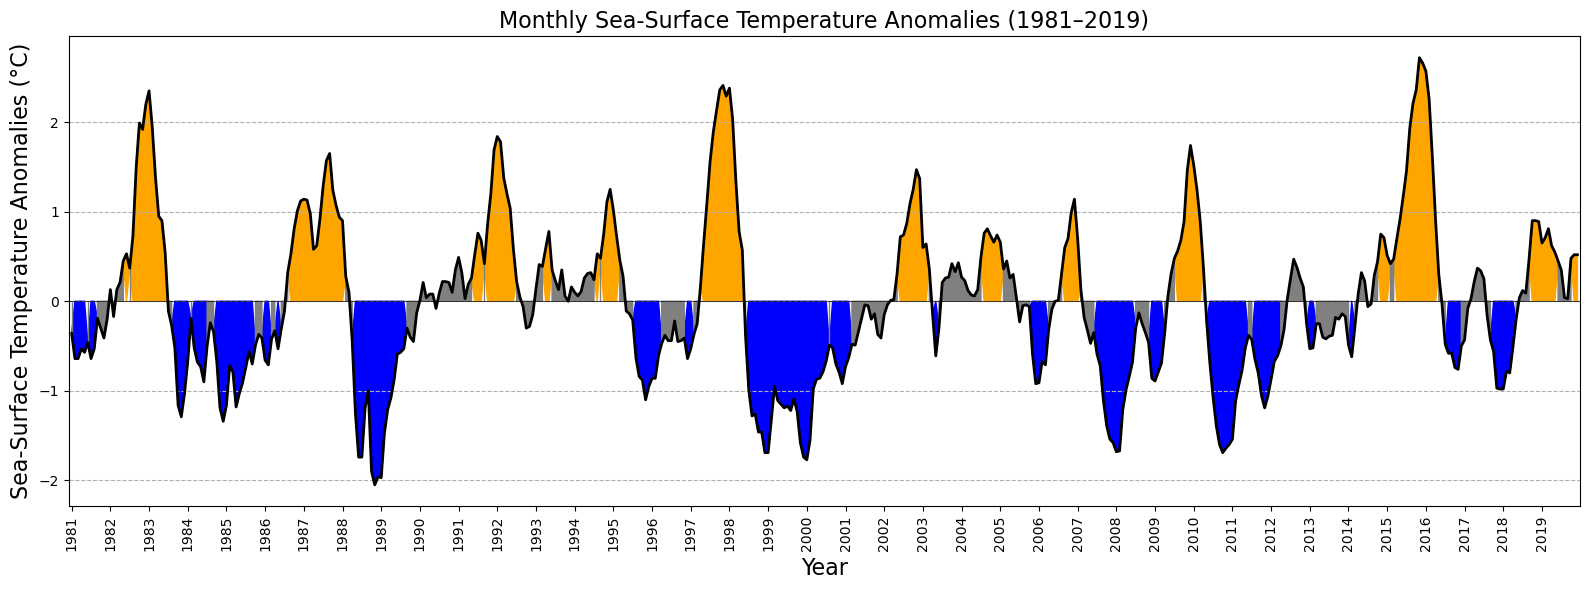

In [9]:
# Extracting the year column
years = ENSO['YEAR']
months = ['JAN', 'FEB', 'MAR', 'APR', 'MAY', 'JUN', 'JUL', 'AUG', 'SEP', 'OCT', 'NOV', 'DEC']
anomalies = ENSO[months]

plt.figure(figsize=(15, 6))

bar_num = len(years) * len(months)

# Extracting the monthly anomaly columns
anomaly_columns = ['JAN', 'FEB', 'MAR', 'APR', 'MAY', 'JUN', 'JUL', 'AUG', 'SEP', 'OCT', 'NOV', 'DEC']

# Filter the data for the years 1981 to 2019
mask = (ENSO['YEAR'] >= 1981) & (ENSO['YEAR'] <= 2019)
filtered_years = ENSO.loc[mask, 'YEAR']
filtered_anomalies = ENSO.loc[mask, anomaly_columns]

# Flatten filtered anomalies for plotting
line_values = filtered_anomalies.values.flatten()

bar_num = len(filtered_years) * len(anomaly_columns)

plt.figure(figsize=(16, 6))
plt.plot(range(len(line_values)), line_values, color='black', linewidth=2)

# Shade portions exceeding anomaly thresholds
plt.fill_between(range(len(line_values)), line_values, where=(line_values >= 0.5), color='orange', interpolate=True)
plt.fill_between(range(len(line_values)), line_values, where=(line_values <= -0.5), color='blue', interpolate=True)
plt.fill_between(range(len(line_values)), line_values, where=((line_values >= -0.5) & (line_values <= 0.5)), color='grey', interpolate=True)

# Customize plot appearance
plt.title('Monthly Sea-Surface Temperature Anomalies (1981–2019)', fontsize=16)
plt.xlabel('Year', fontsize=16)
plt.ylabel('Sea-Surface Temperature Anomalies (°C)', fontsize=16)
plt.xticks(range(0, len(line_values), len(anomaly_columns)), filtered_years, rotation=90)
plt.xlim(-0.9, bar_num - 0.2)
plt.axhline(y=0, color='black', linewidth=0.5)
plt.grid(axis='y', linestyle='--')

plt.tight_layout()
plt.savefig('AnomaliesByYear(1981-2019).png', facecolor="white")
plt.show()

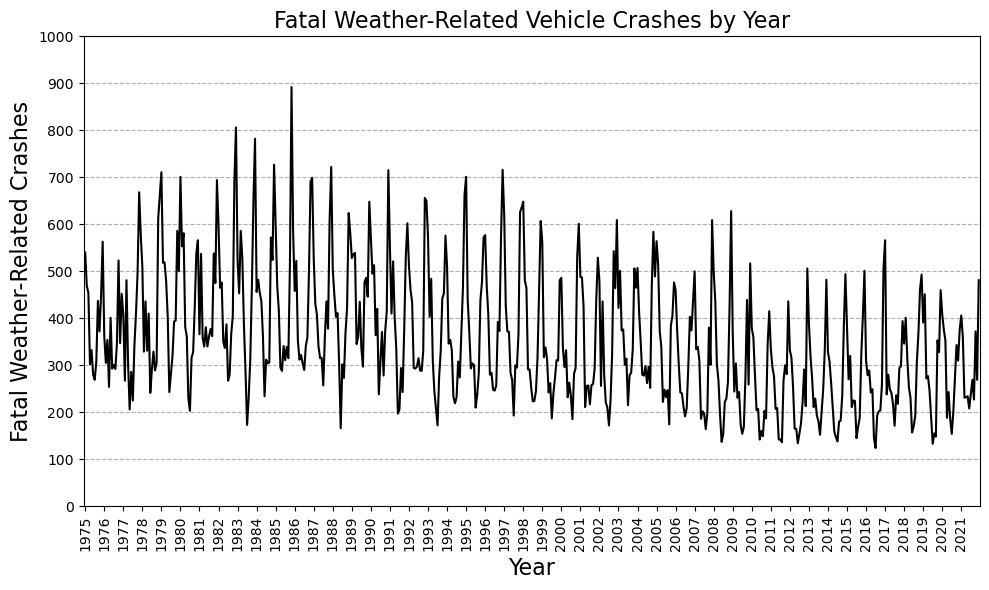

In [10]:
grouped_df = FARS.groupby(['YEAR','MONTH']).size().reset_index(name='Count')
grouped_df.sort_values(['YEAR','MONTH'], inplace = True)
# Get the unique years
unique_years = grouped_df['YEAR'].unique()

# Initialize a list to store the x-tick positions and labels
xtick_positions = []
xtick_labels = []

# Define the month names
month_names = ['JAN', 'FEB', 'MAR', 'APR', 'MAY', 'JUN', 'JUL', 'AUG', 'SEP', 'OCT', 'NOV', 'DEC']

# Iterate over the unique years
for year in unique_years:
    # Get the first month of each year
    first_month = grouped_df[grouped_df['YEAR'] == year]['MONTH'].iloc[0]
    
    # Get the index of the first month for the current year
    index = grouped_df[(grouped_df['YEAR'] == year) & (grouped_df['MONTH'] == first_month)].index[0]
    
    # Add the index to the x-tick positions
    xtick_positions.append(index)
    
    # Generate the x-tick label for the first month of each year
    xtick_labels.append(f"{year}")

# Plotting the line plot
plt.figure(figsize=(10, 6))

plt.plot(range(len(grouped_df)), grouped_df['Count'], color='black')

plt.title('Fatal Weather-Related Vehicle Crashes by Year',fontsize=16)
plt.xlabel('Year',fontsize=16)
plt.ylabel('Fatal Weather-Related Crashes',fontsize=16)

plt.xticks(xtick_positions, xtick_labels, rotation=90)
plt.xlim(-0.9, len(grouped_df) - 0.2)
plt.yticks(range(0, 1001, 100))
plt.grid(axis='y', linestyle='--')
plt.tight_layout()
plt.savefig('FatalCrashesByYearLine2-1.png', facecolor="white")
plt.show()